In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
from lib.models.regnetv3.modules import XBlockV3, Permute, PositionalEncoding
from lib.models.regnetv3.regnet_encoder import RegNetEncoder
from torch import nn
import torch
from lib.data.dataloading import load_nursing_5_class, load_raw
from lib.models import RegNetv3
from lib.config import RAW_DIR
from lib.modules import optimization_loop_xonly, optimization_loop_multi_class
from lib.utils import sample_regnet
from tqdm import tqdm
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [17]:
from lib.models import DAE
CONFIG = {
    'WINDOW_SIZE':2001,
    'WINDOW_STRIDE':2001 // 4,
    'NURSING_STRIDE': 2001,
    'BATCH_SIZE': 512,
    'LEARNING_RATE': 1e-3,
    'CLASS_LR': 3e-4,
    'ENC_LEARNING_RATE': 5e-5,
    'TEST_SIZE': 0.1,
    'NURSING_TEST_SIZE': 0.25,
    'DEVICE': 'cuda:1',
    'DEPTHI': [2,2],
    'WIDTHI': [48,128],
    'MASKPCT': 0.2,
    'PDROPOUT': 0.0
}

# while True:
#     d,w,_ = sample_regnet()
#     CONFIG['DEPTHI'] = d
#     CONFIG['WIDTHI'] = w
#     nparams = sum([p.numel() for p in RegNetDAEv3(CONFIG=CONFIG).parameters()])
#     if nparams > 3_000_000 and nparams < 7_000_000:
#         print(nparams, d, w)
#         break

trainloader, testloader = load_raw(
    RAW_DIR,
    CONFIG['WINDOW_SIZE'],
    test_size=CONFIG['TEST_SIZE'],
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle_test=True,
    chunk_len_hrs=0.25,
    stride=CONFIG['WINDOW_STRIDE']
)
len(trainloader.dataset), len(testloader.dataset)

model = DAE(CONFIG=CONFIG).to(CONFIG['DEVICE'])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'])

outdir = f'dev/10_dae/mask20-3layer'
optimization_loop_xonly(
    model,
    trainloader,
    testloader,
    criterion,
    optimizer,
    epochs=100,
    patience=20,
    config=CONFIG,
    continue_training=False,
    device=CONFIG['DEVICE'],
    outdir=outdir,
    writer=outdir,
)

Using all available sessions
Using Directories: ['2022-12-20_15_10_43.pt', '10-28_13_18_42.pt', '2022-12-10_14_27_45.pt', '2023-11-11_17_50_20.pt', '2022-12-20_11_18_54.pt', '2022-12-08_14_30_54.pt', '2023-11-01_15_49_48.pt', '2022-12-20_10_54_30.pt', '2023-10-26_15_32_20.pt', '2022-12-12_07_03_40.pt', '11-07_17_43_30.pt', '2023-02-11_13_51_34.pt', '11-07_12_58_43.pt', '2024-02-27_09_39_32.pt', '2023-11-02_13_55_22.pt', '2023-11-10_13_11_41.pt', '10-27_00_21_25.pt', '2022-12-21_14_16_02.pt', '2022-12-10_12_57_32.pt', '2018-01-01_13_33_47.pt', '11-07_15_03_24.pt', '11-07_17_29_01.pt', '11-08_08_27_30.pt', '2022-12-19_08_37_36.pt', '2022-12-06_17_27_56.pt', '2018-01-02_18_25_12.pt', '2022-12-06_15_48_49.pt', '11-01_20_34_28.pt', '2022-12-06_18_21_08.pt', '10-27_09_45_42.pt', '2023-11-01_15_47_52.pt', '2024-02-22_18_21_48.pt', '2022-12-08_11_52_09.pt', '2018-01-03_13_28_35.pt', '11-08_07_17_47.pt', '2022-12-08_19_04_00.pt', '11-02_19_28_19.pt', '2024-03-17_13_08_04.pt', '11-10_08_54_24.pt

: Epoch 99: Train Loss: 0.074377: Dev Loss: 0.081921: 100%|██████████| 100/100 [17:44<00:00, 10.64s/it]


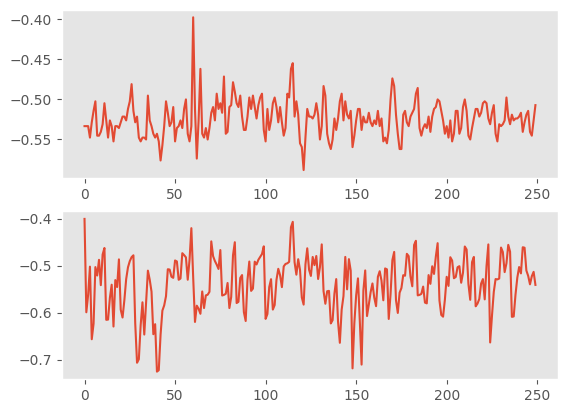

In [11]:
import matplotlib.pyplot as plt
# CONFIG = {
#     'WINDOW_SIZE':2001,
#     'WINDOW_STRIDE':2001,
#     'NURSING_STRIDE': 2001 // 16,
#     'BATCH_SIZE': 256,
#     'LEARNING_RATE': 1e-3,
#     'CLASS_LR': 3e-4,
#     'ENC_LEARNING_RATE': 5e-5,
#     'TEST_SIZE': 0.1,
#     'NURSING_TEST_SIZE': 0.25,
#     'DEVICE': 'cuda:1',
#     'DEPTHI': [1],
#     'WIDTHI': [64],
#     'MASKPCT': 0.0,
#     'PDROPOUT': 0.0
# }
# model = RegNetDAEv3(CONFIG=CONFIG)
X = next(iter(trainloader))
x = model(X.to(CONFIG['DEVICE']))
fig, axes = plt.subplots(2)
axes[0].plot(X[4,0,:250].detach().cpu().numpy())
axes[1].plot(x[4,0,:250].detach().cpu().numpy())
for ax in axes:
    ax.grid()

In [12]:

X = next(iter(testloader))
logits = model(X.to(CONFIG['DEVICE'])).detach().cpu().numpy()
i = slice(0,10)
df = pd.DataFrame({
    'x': X[i,0].flatten(), 
    'y': X[i,1].flatten(), 
    'z': X[i,2].flatten(), 
    'x_pred': logits[i,0].flatten(), 
    'y_pred': logits[i,1].flatten(), 
    'z_pred': logits[i,2].flatten()
})
fig = px.line(df, x=df.index, y=['x', 'x_pred', 'y', 'y_pred', 'z', 'z_pred'])
fig.show(renderer='browser')

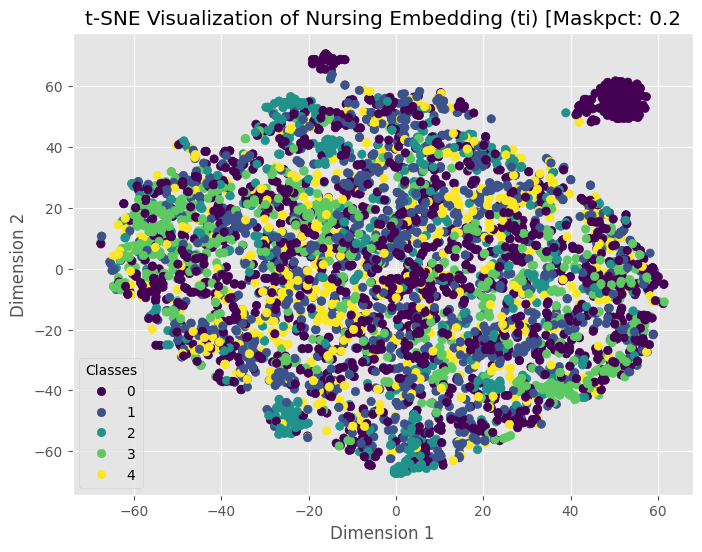

In [10]:
from lib.data.dataloading import load_nursing_5_class

nursing_trainloader, nursing_testloader = load_nursing_5_class(
    range(11,71), 
    CONFIG['WINDOW_SIZE'], 
    test_size=1, 
    batch_size=CONFIG['BATCH_SIZE'],
    stride=CONFIG['WINDOW_SIZE'],
)

embedding = []
Xs = []
ys = []
for i,(X,y) in enumerate(tqdm(nursing_testloader)):
    with torch.no_grad():
        Xs.append(X)
        ys.append(y)
        X = X.view(-1, 3, CONFIG['WINDOW_SIZE'])
        X = X.to(CONFIG['DEVICE'])
        x = model.e(X)
        embedding.append(x.detach().cpu().mean(dim=2))
    
embedding = torch.cat(embedding, dim=0)
Xs = torch.cat(Xs, dim=0)
ys = torch.cat(ys, dim=0)

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

emb_np = embedding.numpy()

# Applying t-SNE to reduce the dimensions to 2
tsne = TSNE(n_components=2)
data_tsne = tsne.fit_transform(emb_np)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data_tsne[:, 0], data_tsne[:, 1], marker='o', c=ys)#, c=cluster_labels, cmap='viridis')
plt.title(f't-SNE Visualization of Nursing Embedding (ti) [Maskpct: {CONFIG["MASKPCT"]}')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(*scatter.legend_elements(), loc="lower left", title="Classes")
plt.show()

# 'NONE':0,
# 'Eating':1,
# 'Exercise':2,
# 'Medication':3,
# 'Smoking':4,

# DataAug

https://arxiv.org/pdf/1702.05538.pdf